# Modelización — Fine-tuning de BETO (Amazon Reviews ES)

Quinto modelo propuesto en la Sección 4.2.2 del informe: fine-tuning de **BETO** (BERT en español, `dccuchile/bert-base-spanish-wwm-cased`) para la clasificación binaria de sentimiento.

Dado el costo computacional de fine-tunear un transformer completo en GPU de laptop (6GB VRAM), se entrena sobre una **muestra estratificada** de 18,000 reseñas (15,000 train / 3,000 test) en vez de las 200,000 completas usadas para los modelos clásicos. Esta decisión de alcance se documenta como limitación en las conclusiones.

In [1]:
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                              precision_score, recall_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE, '-', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: cuda - NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Carga y muestreo estratificado

In [2]:
dataset = load_dataset('SetFit/amazon_reviews_multi_es')
df = pd.DataFrame(dataset['train'])
df = df.rename(columns={'text': 'review_body', 'label': 'stars'})

def map_sentiment(stars):
    return 'negativo' if stars <= 3 else 'positivo'

df['sentimiento'] = df['stars'].apply(map_sentiment)

N_TRAIN, N_TEST = 15000, 3000
df_sample, _ = train_test_split(df, train_size=(N_TRAIN + N_TEST), stratify=df['sentimiento'], random_state=RANDOM_STATE)
df_train, df_test = train_test_split(df_sample, train_size=N_TRAIN, stratify=df_sample['sentimiento'], random_state=RANDOM_STATE)

print('Train:', df_train.shape, '| Test:', df_test.shape)
print(df_train['sentimiento'].value_counts(normalize=True).round(3))

Repo card metadata block was not found. Setting CardData to empty.


Train: (15000, 5) | Test: (3000, 5)
sentimiento
negativo    0.8
positivo    0.2
Name: proportion, dtype: float64


## 2. Tokenización con BETO

In [3]:
MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
MAX_LEN = 96

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

y_train = (df_train['sentimiento'] == 'positivo').astype(int).to_numpy()
y_test = (df_test['sentimiento'] == 'positivo').astype(int).to_numpy()

enc_train = tokenizer(list(df_train['review_body'].astype(str)), truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='pt')
enc_test = tokenizer(list(df_test['review_body'].astype(str)), truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='pt')

class ReviewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = ReviewsDataset(enc_train, y_train)
test_ds = ReviewsDataset(enc_test, y_test)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
print('Batches de entrenamiento:', len(train_loader))

Batches de entrenamiento: 938


## 3. Fine-tuning (loop manual con precisión mixta)

Se usa pérdida ponderada por clase para mantener el mismo manejo de desbalance aplicado a los demás modelos.

In [4]:
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

def evaluar(loader):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
                loss = loss_fn(outputs.logits, batch['labels'])
            total_loss += loss.item()
            all_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
    model.train()
    return total_loss / len(loader), accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average='macro')

# Subconjunto fijo de train (2000 muestras) para monitorear el ajuste por época sin
# recorrer las 15,000 muestras completas en cada evaluación.
train_eval_idx = np.random.RandomState(RANDOM_STATE).choice(len(train_ds), size=2000, replace=False)
train_eval_ds = torch.utils.data.Subset(train_ds, train_eval_idx)
train_eval_loader = DataLoader(train_eval_ds, batch_size=32, shuffle=False)

EPOCHS = 4
historia = []
model.train()
t0 = time.time()

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for step, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
            loss = loss_fn(outputs.logits, batch['labels'])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        if step % 300 == 0:
            print(f'Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}')

    train_loss_avg = epoch_loss / len(train_loader)
    eval_train_loss, eval_train_acc, eval_train_f1 = evaluar(train_eval_loader)
    eval_test_loss, eval_test_acc, eval_test_f1 = evaluar(test_loader)

    historia.append({
        'epoch': epoch + 1,
        'train_loss': train_loss_avg,
        'train_acc_subset': eval_train_acc,
        'train_f1_subset': eval_train_f1,
        'test_loss': eval_test_loss,
        'test_acc': eval_test_acc,
        'test_f1': eval_test_f1,
    })
    print(f'Epoch {epoch+1} completado | Loss train: {train_loss_avg:.4f} | '
          f'Acc train(subset): {eval_train_acc:.4f} | Acc test: {eval_test_acc:.4f} | '
          f'F1-macro test: {eval_test_f1:.4f}')

print(f'Fine-tuning completado en {(time.time()-t0)/60:.1f} min')
df_historia = pd.DataFrame(historia)
df_historia.to_csv('../resultados/tablas/historia_entrenamiento_beto_amazon.csv', index=False)
df_historia

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch 1 | Step 0/938 | Loss: 0.6028


Epoch 1 | Step 300/938 | Loss: 0.2358


Epoch 1 | Step 600/938 | Loss: 0.3543


...

Epoch 4 | Step 300/938 | Loss: 0.0236


Epoch 4 | Step 600/938 | Loss: 0.1895


Epoch 4 | Step 900/938 | Loss: 0.1083


Epoch 4 completado | Loss train: 0.1735 | Acc train(subset): 0.9715 | Acc test: 0.8700 | F1-macro test: 0.8034
Fine-tuning completado en 8.3 min


,epoch,train_loss,train_acc_subset,train_f1_subset,test_loss,test_acc,test_f1
0,1,0.409405,0.8405,0.804422,0.349002,0.818333,0.773308
1,2,0.310279,0.9015,0.869275,0.381723,0.847667,0.794775
2,3,0.238880,0.9385,0.914914,0.487709,0.859667,0.802402
3,4,0.173482,0.9715,0.958513,0.636317,0.870000,0.803410


## 4. Evaluación en el conjunto de prueba

In [5]:
model.eval()
y_pred, y_proba = [], []

with torch.no_grad():
    for batch in test_loader:
        batch_gpu = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
        outputs = model(**batch_gpu)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_proba.extend(probs)

y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

resultado_beto = {
    'Modelo': 'BETO (fine-tuned)',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
    'F1-macro': f1_score(y_test, y_pred, average='macro'),
    'Precision (positivo)': precision_score(y_test, y_pred),
    'Recall (positivo)': recall_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'Tiempo entrenamiento (s)': None
}
print(resultado_beto)

{'Modelo': 'BETO (fine-tuned)', 'Accuracy': 0.87, 'Balanced Accuracy': 0.81375, 'F1-macro': 0.8034103763027843, 'Precision (positivo)': 0.6605504587155964, 'Recall (positivo)': 0.72, 'ROC-AUC': 0.9110166666666666, 'Tiempo entrenamiento (s)': None}


### Curva de aprendizaje de BETO (train vs. test por época)

Se aumentó el número de épocas de 2 a 4 y se registró el desempeño en un subconjunto fijo de entrenamiento (2,000 reseñas) y en el conjunto de prueba completo al final de cada época, para diagnosticar sobreajuste.

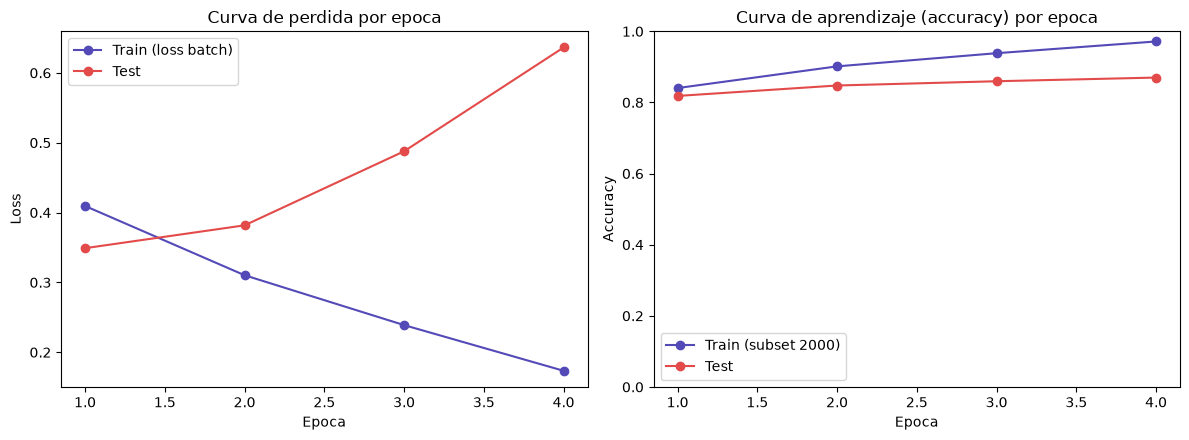

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_historia['epoch'], df_historia['train_loss'], 'o-', color='#534AB7', label='Train (loss batch)')
axes[0].plot(df_historia['epoch'], df_historia['test_loss'], 'o-', color='#E24B4A', label='Test')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de perdida por epoca')
axes[0].legend()

axes[1].plot(df_historia['epoch'], df_historia['train_acc_subset'], 'o-', color='#534AB7', label='Train (subset 2000)')
axes[1].plot(df_historia['epoch'], df_historia['test_acc'], 'o-', color='#E24B4A', label='Test')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de aprendizaje (accuracy) por epoca')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig('../resultados/figuras/fig16b_curva_aprendizaje_beto_amazon.png', bbox_inches='tight')
plt.show()

## 5. Matriz de confusión y comparación final con los modelos clásicos

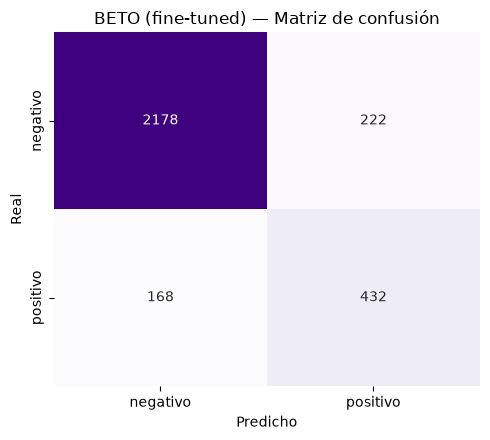

In [7]:
fig, ax = plt.subplots(figsize=(5, 4.5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax,
            xticklabels=['negativo', 'positivo'], yticklabels=['negativo', 'positivo'])
ax.set_title('BETO (fine-tuned) — Matriz de confusión')
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('../resultados/figuras/fig14_matriz_confusion_beto.png', bbox_inches='tight')
plt.show()

In [8]:
df_clasicos = pd.read_csv('../resultados/tablas/resultados_amazon.csv')
df_final = pd.concat([df_clasicos, pd.DataFrame([resultado_beto])], ignore_index=True)
df_final = df_final.sort_values('F1-macro', ascending=False).reset_index(drop=True)
df_final.to_csv('../resultados/tablas/resultados_amazon_final_con_beto.csv', index=False)
df_final

,Modelo,Accuracy,Balanced Accuracy,F1-macro,Precision (positivo),Recall (positivo),ROC-AUC,Tiempo entrenamiento (s)
0,BETO (fine-tuned),0.870000,0.813750,0.803410,0.660550,0.720000,0.911017,None
1,Regresión Logística,0.816250,0.811703,0.756742,0.526604,0.804125,0.885541,1.4
2,XGBoost,0.797225,0.774266,0.728608,0.495331,0.736000,0.858447,136.7
3,SVM Lineal,0.841725,0.680672,0.707930,0.669373,0.412250,0.874540,2.8
4,Naive Bayes Multinomial,0.834625,0.649984,0.677745,0.669274,0.342250,0.876402,0.0


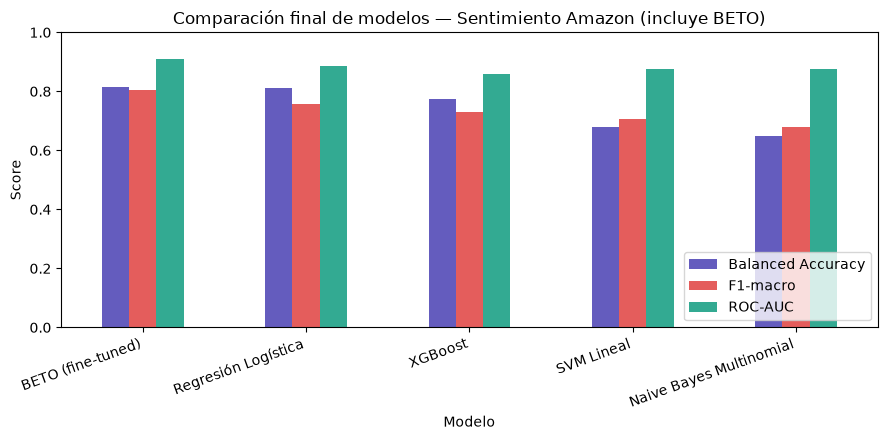

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
metricas_plot = df_final.set_index('Modelo')[['Balanced Accuracy', 'F1-macro', 'ROC-AUC']]
metricas_plot.plot(kind='bar', ax=ax, color=['#534AB7', '#E24B4A', '#1DA186'], alpha=0.9)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Comparación final de modelos — Sentimiento Amazon (incluye BETO)')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../resultados/figuras/fig15_comparacion_final_amazon_con_beto.png', bbox_inches='tight')
plt.show()

## 6. Guardar modelo fine-tuneado (para la app de stakeholders)

Se persisten los pesos y el tokenizer para que la aplicacion Streamlit pueda cargarlos localmente sin re-entrenar. Estos pesos NO se suben a GitHub (repositorio pesado, ~440MB) — se documentan en el .gitignore.

In [10]:
import os
OUT_DIR = '../app/modelos/beto_amazon'
os.makedirs(OUT_DIR, exist_ok=True)
model.save_pretrained(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)
print('BETO Amazon guardado en', OUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BETO Amazon guardado en ../app/modelos/beto_amazon
